In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
import time

# Styling configuration for clean, publication-ready figures
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.35
plt.rcParams['grid.linestyle'] = '--'

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
def plot_covariance_ellipse(mean, C, sigma, ax, n_std=2.0, edgecolor='red', facecolor='none', alpha=0.6, lw=1.5, label=None):
    """
    Plots an n_std confidence ellipse of the Gaussian distribution N(mean, sigma^2 * C) on a 2D matplotlib axis.
    """
    if C.shape[0] != 2:
        return
    
    # Total covariance matrix Sigma = sigma^2 * C
    cov = (sigma ** 2) * C
    
    # Eigen-decomposition of covariance
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    
    # Ensure positive eigenvalues
    eigenvalues = np.maximum(eigenvalues, 1e-16)
    
    # Sort eigenvalues in descending order
    order = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]
    
    # Calculate angle of rotation (in degrees)
    angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
    
    # Width and height of ellipse correspond to 2 * n_std * standard deviations
    width, height = 2 * n_std * np.sqrt(eigenvalues)
    
    ellipse = Ellipse(xy=mean, width=width, height=height, angle=angle,
                      edgecolor=edgecolor, facecolor=facecolor, alpha=alpha, linewidth=lw, label=label)
    ax.add_patch(ellipse)
    return ellipse

In [3]:
class BenchmarkFunctions:
    @staticmethod
    def sphere(x):
        """Isotropic Quadratic: f(x) = ||x||^2"""
        return np.sum(np.asarray(x)**2)

    @staticmethod
    def ill_conditioned_2d(x, cond=100.0):
        """Anisotropic 2D Quadratic: f(x1, x2) = x1^2 + cond * x2^2"""
        x = np.asarray(x)
        return x[0]**2 + cond * (x[1]**2)

    @staticmethod
    def create_rotated_quadratic(theta_deg=30.0, cond=100.0):
        """Creates a rotated 2D quadratic f(x) = x^T Q^T Lambda Q x"""
        theta = np.radians(theta_deg)
        # 2D Rotation matrix
        Q = np.array([
            [np.cos(theta), -np.sin(theta)],
            [np.sin(theta),  np.cos(theta)]
        ])
        Lambda = np.diag([1.0, cond])
        A = Q.T @ Lambda @ Q
        
        def rotated_quadratic(x):
            x = np.asarray(x)
            return float(x.T @ A @ x)
        
        return rotated_quadratic, A, Q, Lambda

    @staticmethod
    def rosenbrock_2d(x):
        """Rosenbrock Banana function: f(x1, x2) = 100(x2 - x1^2)^2 + (1 - x1)^2"""
        x = np.asarray(x)
        return 100.0 * (x[1] - x[0]**2)**2 + (1.0 - x[0])**2

    @staticmethod
    def rastrigin(x):
        """Rastrigin multimodal function: f(x) = 10d + sum(x_i^2 - 10*cos(2*pi*x_i))"""
        x = np.asarray(x)
        d = len(x)
        return 10.0 * d + np.sum(x**2 - 10.0 * np.cos(2.0 * np.pi * x))

In [4]:
def random_search(f, dim, bounds, max_evals=5000, seed=42):
    """
    Baseline Uniform Random Search in bounded domain.
    """
    np.random.seed(seed)
    low, high = bounds
    best_x = None
    best_f = float('inf')
    
    history_f = []
    history_evals = []
    
    for ev in range(1, max_evals + 1):
        candidate = np.random.uniform(low, high, size=dim)
        val = f(candidate)
        if val < best_f:
            best_f = val
            best_x = candidate.copy()
        
        history_f.append(best_f)
        history_evals.append(ev)
        
    return {
        'name': 'Random Search',
        'best_x': best_x,
        'best_f': best_f,
        'history_f': np.array(history_f),
        'history_evals': np.array(history_evals)
    }

In [5]:
def isotropic_es(f, x0, sigma0=1.0, lam=20, mu=10, max_iter=200, adapt_step=True, seed=42):
    """
    Isotropic (mu/mu_w, lambda)-Evolution Strategy (Section 2).
    Samples: X_i = m + sigma * Z_i, where Z_i ~ N(0, I).
    """
    np.random.seed(seed)
    dim = len(x0)
    m = np.array(x0, dtype=float)
    sigma = float(sigma0)
    
    # Logarithmic recombination weights
    weights = np.log(mu + 0.5) - np.log(np.arange(1, mu + 1))
    weights /= np.sum(weights)
    mueff = 1.0 / np.sum(weights**2)
    
    # Cumulative Step-size Adaptation (CSA) constants for isotropic search
    cs = (mueff + 2.0) / (dim + mueff + 5.0)
    ds = 1.0 + 2.0 * max(0.0, np.sqrt((mueff - 1.0) / (dim + 1.0)) - 1.0) + cs
    chiN = np.sqrt(dim) * (1.0 - 1.0 / (4.0 * dim) + 1.0 / (21.0 * dim**2))
    ps = np.zeros(dim)
    
    history_f = []
    history_mean = [m.copy()]
    history_sigma = [sigma]
    history_evals = []
    population_history = []
    
    total_evals = 0
    best_f = f(m)
    best_x = m.copy()
    
    for gen in range(max_iter):
        # 1. Sample lambda candidates
        Z = np.random.randn(lam, dim)
        X = m + sigma * Z
        
        # 2. Evaluate objective
        fitness = np.array([f(x) for x in X])
        total_evals += lam
        
        # 3. Sort and select best mu
        idx = np.argsort(fitness)
        X_sel = X[idx[:mu]]
        Z_sel = Z[idx[:mu]]
        
        if fitness[idx[0]] < best_f:
            best_f = fitness[idx[0]]
            best_x = X[idx[0]].copy()
            
        # 4. Update mean
        z_w = np.sum(weights[:, None] * Z_sel, axis=0)
        m = m + sigma * z_w
        
        # 5. Adapt step size via CSA if enabled
        if adapt_step:
            ps = (1.0 - cs) * ps + np.sqrt(cs * (2.0 - cs) * mueff) * z_w
            sigma = sigma * np.exp((cs / ds) * (np.linalg.norm(ps) / chiN - 1.0))
        
        history_f.append(best_f)
        history_mean.append(m.copy())
        history_sigma.append(sigma)
        history_evals.append(total_evals)
        if gen % 5 == 0 or gen == max_iter - 1:
            population_history.append((gen, X.copy()))
            
    return {
        'name': 'Isotropic ES',
        'best_x': best_x,
        'best_f': best_f,
        'history_f': np.array(history_f),
        'history_mean': np.array(history_mean),
        'history_sigma': np.array(history_sigma),
        'history_evals': np.array(history_evals),
        'population_history': population_history
    }

In [6]:
def simplified_cma_es(f, x0, sigma0=1.0, c_cov=0.2, lam=20, mu=10, max_iter=200, seed=42):
    """
    Simplified Covariance Adaptation (Section 5, Eq. 2).
    Samples: X_i = m + sigma * C^(1/2) Z_i
    Covariance update: C_{n+1} = (1 - c) C_n + c * sum_{i=1}^mu w_i y_i y_i^T
    """
    np.random.seed(seed)
    dim = len(x0)
    m = np.array(x0, dtype=float)
    sigma = float(sigma0)
    C = np.eye(dim)
    
    weights = np.log(mu + 0.5) - np.log(np.arange(1, mu + 1))
    weights /= np.sum(weights)
    mueff = 1.0 / np.sum(weights**2)
    
    cs = (mueff + 2.0) / (dim + mueff + 5.0)
    ds = 1.0 + 2.0 * max(0.0, np.sqrt((mueff - 1.0) / (dim + 1.0)) - 1.0) + cs
    chiN = np.sqrt(dim) * (1.0 - 1.0 / (4.0 * dim) + 1.0 / (21.0 * dim**2))
    ps = np.zeros(dim)
    
    history_f = []
    history_mean = [m.copy()]
    history_sigma = [sigma]
    history_C = [C.copy()]
    history_evals = []
    population_history = []
    
    total_evals = 0
    best_f = f(m)
    best_x = m.copy()
    
    for gen in range(max_iter):
        # Eigendecomposition of C for stable sampling C = B D^2 B^T => C^(1/2) = B D B^T
        D2, B = np.linalg.eigh(C)
        D2 = np.maximum(D2, 1e-16)
        D = np.sqrt(D2)
        C_sqrt = B @ np.diag(D) @ B.T
        
        # 1. Sample
        Z = np.random.randn(lam, dim)
        Y = (C_sqrt @ Z.T).T  # Y_i = C^(1/2) Z_i
        X = m + sigma * Y
        
        # 2. Evaluate and sort
        fitness = np.array([f(x) for x in X])
        total_evals += lam
        
        idx = np.argsort(fitness)
        X_sel = X[idx[:mu]]
        Y_sel = Y[idx[:mu]]
        Z_sel = Z[idx[:mu]]
        
        if fitness[idx[0]] < best_f:
            best_f = fitness[idx[0]]
            best_x = X[idx[0]].copy()
            
        # 3. Update mean
        y_w = np.sum(weights[:, None] * Y_sel, axis=0)
        m = m + sigma * y_w
        
        # 4. Rank-mu Covariance update (Eq. 2)
        rank_mu = np.zeros((dim, dim))
        for i in range(mu):
            yi = Y_sel[i]
            rank_mu += weights[i] * np.outer(yi, yi)
            
        C = (1.0 - c_cov) * C + c_cov * rank_mu
        # Enforce symmetry
        C = (C + C.T) / 2.0
        
        # 5. Adapt step size via CSA
        C_inv_sqrt = B @ np.diag(1.0 / D) @ B.T
        z_w = C_inv_sqrt @ y_w
        ps = (1.0 - cs) * ps + np.sqrt(cs * (2.0 - cs) * mueff) * z_w
        sigma = sigma * np.exp((cs / ds) * (np.linalg.norm(ps) / chiN - 1.0))
        
        history_f.append(best_f)
        history_mean.append(m.copy())
        history_sigma.append(sigma)
        history_C.append(C.copy())
        history_evals.append(total_evals)
        if gen % 5 == 0 or gen == max_iter - 1:
            population_history.append((gen, X.copy()))
            
    return {
        'name': 'Simplified CMA-ES',
        'best_x': best_x,
        'best_f': best_f,
        'history_f': np.array(history_f),
        'history_mean': np.array(history_mean),
        'history_sigma': np.array(history_sigma),
        'history_C': np.array(history_C),
        'history_evals': np.array(history_evals),
        'population_history': population_history
    }

In [7]:
def standard_cma_es(f, x0, sigma0=1.0, max_iter=200, lam=None, seed=42):
    """
    Standard Modern CMA-ES (Hansen 2016 Tutorial) with:
    - Cumulative Step-size Adaptation (CSA)
    - Rank-1 update via evolution path p_c
    - Rank-mu update via selected mutations
    """
    np.random.seed(seed)
    dim = len(x0)
    m = np.array(x0, dtype=float)
    sigma = float(sigma0)
    
    # Population size heuristics
    if lam is None:
        lam = 4 + int(3 * np.log(dim))
    mu = int(lam / 2)
    
    # Recombination weights
    weights = np.log(mu + 0.5) - np.log(np.arange(1, mu + 1))
    weights /= np.sum(weights)
    mueff = 1.0 / np.sum(weights**2)
    
    # Strategy parameter setting: Adaptation parameters
    cc = (4.0 + mueff / dim) / (dim + 4.0 + 2.0 * mueff / dim)
    cs = (mueff + 2.0) / (dim + mueff + 5.0)
    c1 = 2.0 / ((dim + 1.3)**2 + mueff)
    cmu = min(1.0 - c1, 2.0 * (mueff - 2.0 + 1.0 / mueff) / ((dim + 2.0)**2 + mueff))
    damps = 1.0 + 2.0 * max(0.0, np.sqrt((mueff - 1.0) / (dim + 1.0)) - 1.0) + cs
    
    # Initialize dynamic strategy parameters
    pc = np.zeros(dim)
    ps = np.zeros(dim)
    B = np.eye(dim)
    D = np.ones(dim)
    C = np.eye(dim)
    chiN = np.sqrt(dim) * (1.0 - 1.0 / (4.0 * dim) + 1.0 / (21.0 * dim**2))
    
    history_f = []
    history_mean = [m.copy()]
    history_sigma = [sigma]
    history_C = [C.copy()]
    history_evals = []
    population_history = []
    
    total_evals = 0
    best_f = f(m)
    best_x = m.copy()
    
    for gen in range(max_iter):
        # 1. Sample population: X_k = m + sigma * B * D * Z_k
        Z = np.random.randn(lam, dim)
        Y = (B @ np.diag(D) @ Z.T).T  # Step offsets y_k = B D z_k
        X = m + sigma * Y
        
        # 2. Evaluate fitness
        fitness = np.array([f(x) for x in X])
        total_evals += lam
        
        # 3. Sort by fitness
        idx = np.argsort(fitness)
        X_sel = X[idx[:mu]]
        Y_sel = Y[idx[:mu]]
        Z_sel = Z[idx[:mu]]
        
        if fitness[idx[0]] < best_f:
            best_f = fitness[idx[0]]
            best_x = X[idx[0]].copy()
            
        # 4. Selection and mean update
        y_w = np.sum(weights[:, None] * Y_sel, axis=0)
        m_old = m.copy()
        m = m + sigma * y_w
        
        # 5. Cumulation: Update evolution paths
        C_inv_sqrt = B @ np.diag(1.0 / D) @ B.T
        ps = (1.0 - cs) * ps + np.sqrt(cs * (2.0 - cs) * mueff) * (C_inv_sqrt @ y_w)
        
        # Heaviside function for h_sigma to stall covariance path when sigma explodes
        norm_ps = np.linalg.norm(ps)
        hsig_threshold = (1.4 + 2.0 / (dim + 1.0)) * chiN
        hsig = 1.0 if (norm_ps / np.sqrt(1.0 - (1.0 - cs)**(2.0 * (gen + 1)))) < hsig_threshold else 0.0
        
        pc = (1.0 - cc) * pc + hsig * np.sqrt(cc * (2.0 - cc) * mueff) * y_w
        
        # 6. Adapt Covariance Matrix (Rank-1 + Rank-mu)
        rank_mu = np.zeros((dim, dim))
        for i in range(mu):
            rank_mu += weights[i] * np.outer(Y_sel[i], Y_sel[i])
            
        delta_hsig = (1.0 - hsig) * cc * (2.0 - cc)
        C = (1.0 - c1 - cmu + delta_hsig * c1) * C + c1 * np.outer(pc, pc) + cmu * rank_mu
        C = (C + C.T) / 2.0  # Enforce symmetry
        
        # 7. Adapt step size sigma
        sigma = sigma * np.exp((cs / damps) * (norm_ps / chiN - 1.0))
        
        # 8. Eigendecomposition C = B D^2 B^T
        # Eigendecomposition is O(d^3), done every iteration (or every few iterations for large d)
        D2, B = np.linalg.eigh(C)
        D2 = np.maximum(D2, 1e-16)
        D = np.sqrt(D2)
        
        history_f.append(best_f)
        history_mean.append(m.copy())
        history_sigma.append(sigma)
        history_C.append(C.copy())
        history_evals.append(total_evals)
        if gen % 5 == 0 or gen == max_iter - 1:
            population_history.append((gen, X.copy()))
            
    return {
        'name': 'Standard CMA-ES',
        'best_x': best_x,
        'best_f': best_f,
        'history_f': np.array(history_f),
        'history_mean': np.array(history_mean),
        'history_sigma': np.array(history_sigma),
        'history_C': np.array(history_C),
        'history_evals': np.array(history_evals),
        'population_history': population_history
    }

In [8]:
# Setup Experiment 1 in 2D and 10D
x0_2d = np.array([4.0, 4.0])
f_sphere = BenchmarkFunctions.sphere

# Run algorithms in 2D
res_rs_2d = random_search(f_sphere, dim=2, bounds=(-6, 6), max_evals=2000)
res_es_2d = isotropic_es(f_sphere, x0_2d, sigma0=1.0, max_iter=80)
res_cma_2d = standard_cma_es(f_sphere, x0_2d, sigma0=1.0, max_iter=80)

# Run in 10D for dimension scaling comparison
x0_10d = 4.0 * np.ones(10)
res_rs_10d = random_search(f_sphere, dim=10, bounds=(-6, 6), max_evals=3000)
res_es_10d = isotropic_es(f_sphere, x0_10d, sigma0=1.0, max_iter=150)
res_cma_10d = standard_cma_es(f_sphere, x0_10d, sigma0=1.0, max_iter=150)

print("Experiment 1 optimization finished!")

Experiment 1 optimization finished!


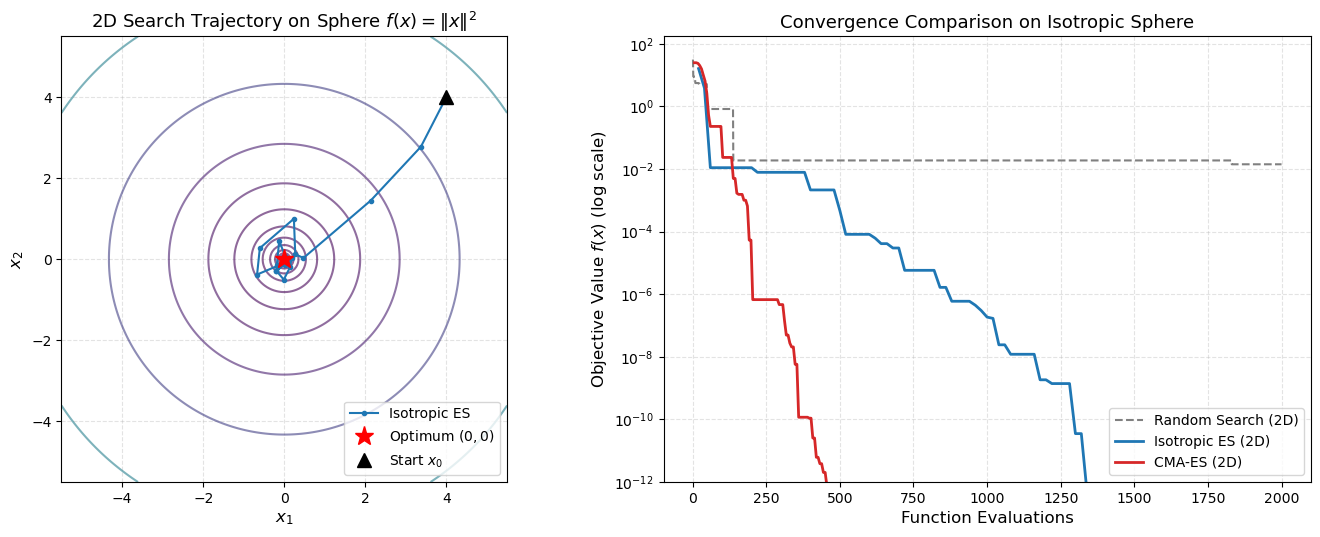

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Left Plot: 2D Trajectories on Contour
ax = axes[0]
x_grid = np.linspace(-5.5, 5.5, 200)
y_grid = np.linspace(-5.5, 5.5, 200)
X_mesh, Y_mesh = np.meshgrid(x_grid, y_grid)
Z_mesh = X_mesh**2 + Y_mesh**2

cs = ax.contour(X_mesh, Y_mesh, Z_mesh, levels=np.logspace(-2, 2, 12), cmap='viridis', alpha=0.6)
ax.plot(res_es_2d['history_mean'][:, 0], res_es_2d['history_mean'][:, 1], 'o-', color='#1f77b4', 
        label='Isotropic ES', markersize=3, lw=1.5)
# ax.plot(res_cma_2d['history_mean'][:, 0], res_cma_2d['history_mean'][:, 1], 's-', color='#d62728', 
        # label='CMA-ES', markersize=3, lw=1.5)
ax.plot(0, 0, 'r*', markersize=14, label='Optimum $(0,0)$')
ax.plot(x0_2d[0], x0_2d[1], 'k^', markersize=10, label='Start $x_0$')
ax.set_title('2D Search Trajectory on Sphere $f(x) = \|x\|^2$')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.legend(loc='lower right')
ax.set_aspect('equal')

# Right Plot: Convergence comparison (2D and 10D)
ax = axes[1]
ax.semilogy(res_rs_2d['history_evals'], res_rs_2d['history_f'], '--', color='gray', label='Random Search (2D)', lw=1.5)
ax.semilogy(res_es_2d['history_evals'], res_es_2d['history_f'], '-', color='#1f77b4', label='Isotropic ES (2D)', lw=2)
ax.semilogy(res_cma_2d['history_evals'], res_cma_2d['history_f'], '-', color='#d62728', label='CMA-ES (2D)', lw=2)

# ax.semilogy(res_rs_10d['history_evals'], res_rs_10d['history_f'], ':', color='black', label='Random Search (10D)', lw=1.5)
# ax.semilogy(res_es_10d['history_evals'], res_es_10d['history_f'], '--', color='#1f77b4', label='Isotropic ES (10D)', lw=2)
# ax.semilogy(res_cma_10d['history_evals'], res_cma_10d['history_f'], '--', color='#d62728', label='CMA-ES (10D)', lw=2)

ax.set_title('Convergence Comparison on Isotropic Sphere')
ax.set_xlabel('Function Evaluations')
ax.set_ylabel('Objective Value $f(x)$ (log scale)')
ax.set_ylim(bottom=1e-12)
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

Ill-Condition Case

In [14]:
f_ill = BenchmarkFunctions.ill_conditioned_2d
x0_ill = np.array([4.0, 4.0])

# Run all 3 algorithms on the ill-conditioned problem
res_es_ill = isotropic_es(f_ill, x0_ill, sigma0=0.5, lam=20, mu=10, max_iter=200)
res_simp_ill = simplified_cma_es(f_ill, x0_ill, sigma0=0.5, c_cov=0.2, lam=20, mu=10, max_iter=150)
res_cma_ill = standard_cma_es(f_ill, x0_ill, sigma0=0.5, lam=20, max_iter=150)

print("Experiment 2 optimization finished!")

Experiment 2 optimization finished!


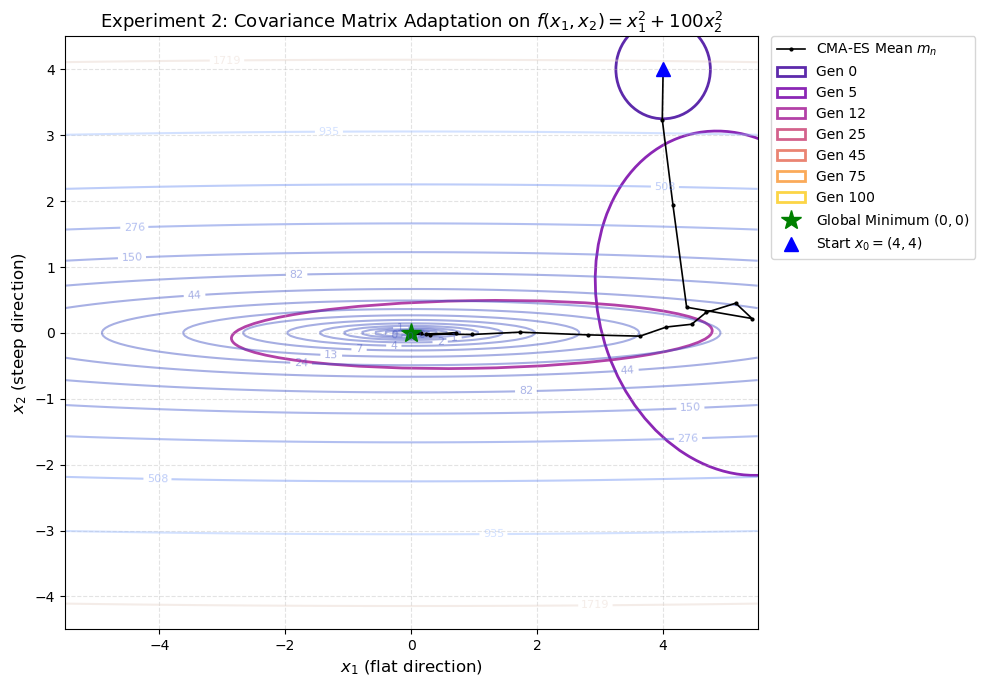

In [15]:
# Figure: Covariance Ellipse Adaptation on Ill-Conditioned Quadratic
fig, ax = plt.subplots(figsize=(10, 7))

x_grid = np.linspace(-5.5, 5.5, 300)
y_grid = np.linspace(-4.5, 4.5, 300)
X_mesh, Y_mesh = np.meshgrid(x_grid, y_grid)
Z_mesh = X_mesh**2 + 100.0 * (Y_mesh**2)

# Plot landscape contours
cs = ax.contour(X_mesh, Y_mesh, Z_mesh, levels=np.logspace(-1, 3.5, 18), cmap='coolwarm', alpha=0.45)
ax.clabel(cs, inline=1, fontsize=8, fmt='%.0f')

# Plot trajectory
means = res_cma_ill['history_mean']
ax.plot(means[:, 0], means[:, 1], 'k.-', markersize=4, lw=1.2, label='CMA-ES Mean $m_n$')

# Select generations to visualize covariance ellipses
gen_snapshots = [0, 5, 12, 25, 45, 75, 100]
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(gen_snapshots)))

for i, gen in enumerate(gen_snapshots):
    if gen < len(res_cma_ill['history_C']):
        m_g = res_cma_ill['history_mean'][gen]
        C_g = res_cma_ill['history_C'][gen]
        s_g = res_cma_ill['history_sigma'][gen]
        plot_covariance_ellipse(m_g, C_g, s_g, ax, n_std=1.5, edgecolor=colors[i], 
                                lw=2.0, alpha=0.85, label=f'Gen {gen}')

ax.plot(0, 0, 'g*', markersize=15, label='Global Minimum $(0,0)$')
ax.plot(x0_ill[0], x0_ill[1], 'b^', markersize=10, label='Start $x_0 = (4,4)$')

ax.set_title('Experiment 2: Covariance Matrix Adaptation on $f(x_1, x_2) = x_1^2 + 100 x_2^2$', fontsize=13)
ax.set_xlabel('$x_1$ (flat direction)')
ax.set_ylabel('$x_2$ (steep direction)')
ax.set_xlim(-5.5, 5.5)
ax.set_ylim(-4.5, 4.5)
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0.)
plt.tight_layout()
plt.show()

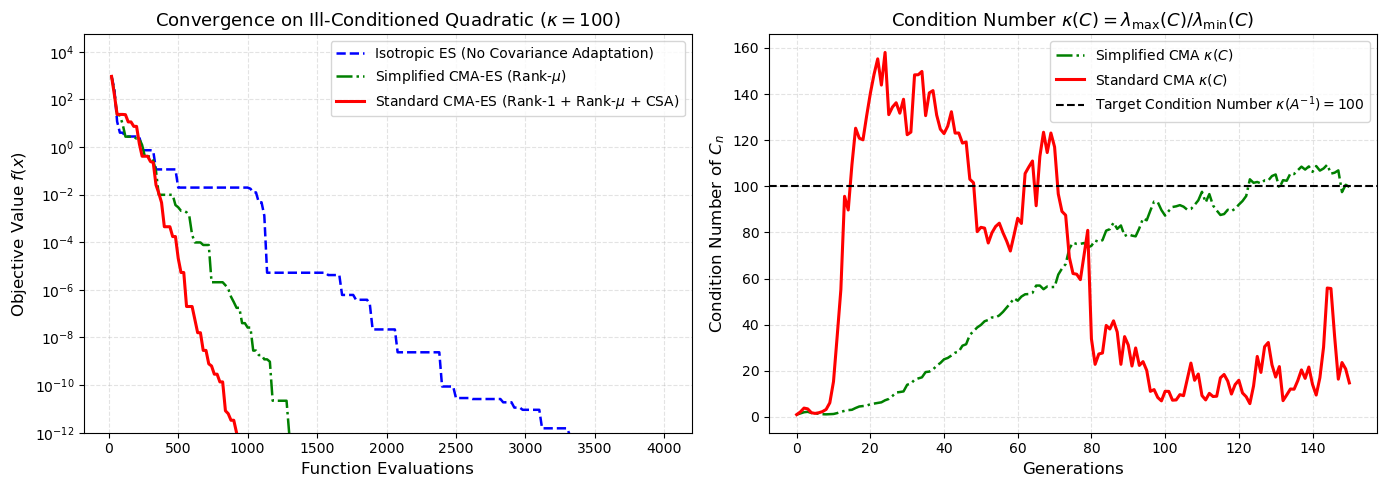

In [16]:
# Figure: Convergence curves and Covariance Matrix Condition Number Evolution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Convergence curves
ax1 = axes[0]
ax1.semilogy(res_es_ill['history_evals'], res_es_ill['history_f'], 'b--', lw=1.8, label='Isotropic ES (No Covariance Adaptation)')
ax1.semilogy(res_simp_ill['history_evals'], res_simp_ill['history_f'], 'g-.', lw=1.8, label='Simplified CMA-ES (Rank-$\mu$)')
ax1.semilogy(res_cma_ill['history_evals'], res_cma_ill['history_f'], 'r-', lw=2.2, label='Standard CMA-ES (Rank-1 + Rank-$\mu$ + CSA)')
ax1.set_title('Convergence on Ill-Conditioned Quadratic ($\kappa=100$)')
ax1.set_xlabel('Function Evaluations')
ax1.set_ylabel('Objective Value $f(x)$')
ax1.set_ylim(bottom=1e-12)
ax1.legend()

# 2. Condition number of C_n over generations
ax2 = axes[1]
cond_simp = [np.linalg.cond(C) for C in res_simp_ill['history_C']]
cond_cma = [np.linalg.cond(C) for C in res_cma_ill['history_C']]

ax2.plot(cond_simp, 'g-.', lw=1.8, label='Simplified CMA $\kappa(C)$')
ax2.plot(cond_cma, 'r-', lw=2.2, label='Standard CMA $\kappa(C)$')
ax2.axhline(y=100.0, color='k', linestyle='--', lw=1.5, label='Target Condition Number $\kappa(A^{-1}) = 100$')
ax2.set_title('Condition Number $\kappa(C) = \lambda_{\max}(C)/\lambda_{\min}(C)$')
ax2.set_xlabel('Generations')
ax2.set_ylabel('Condition Number of $C_n$')
ax2.legend()

plt.tight_layout()
plt.show()

Rotation Matrix

In [19]:
theta_deg = 35.0
f_rot, A_rot, Q_rot, Lambda_rot = BenchmarkFunctions.create_rotated_quadratic(theta_deg=theta_deg, cond=100.0)
x0_rot = np.array([4.0, 4.0])

# Run algorithms on rotated landscape
res_es_rot = isotropic_es(f_rot, x0_rot, sigma0=0.5, lam=20, mu=10, max_iter=200)
res_simp_rot = simplified_cma_es(f_rot, x0_rot, sigma0=0.5, c_cov=0.2, lam=20, mu=10, max_iter=160)
res_cma_rot = standard_cma_es(f_rot, x0_rot, sigma0=0.5, lam=20, max_iter=160)

print(f"Experiment 3 optimization on {theta_deg} deg rotated landscape finished!")

Experiment 3 optimization on 35.0 deg rotated landscape finished!


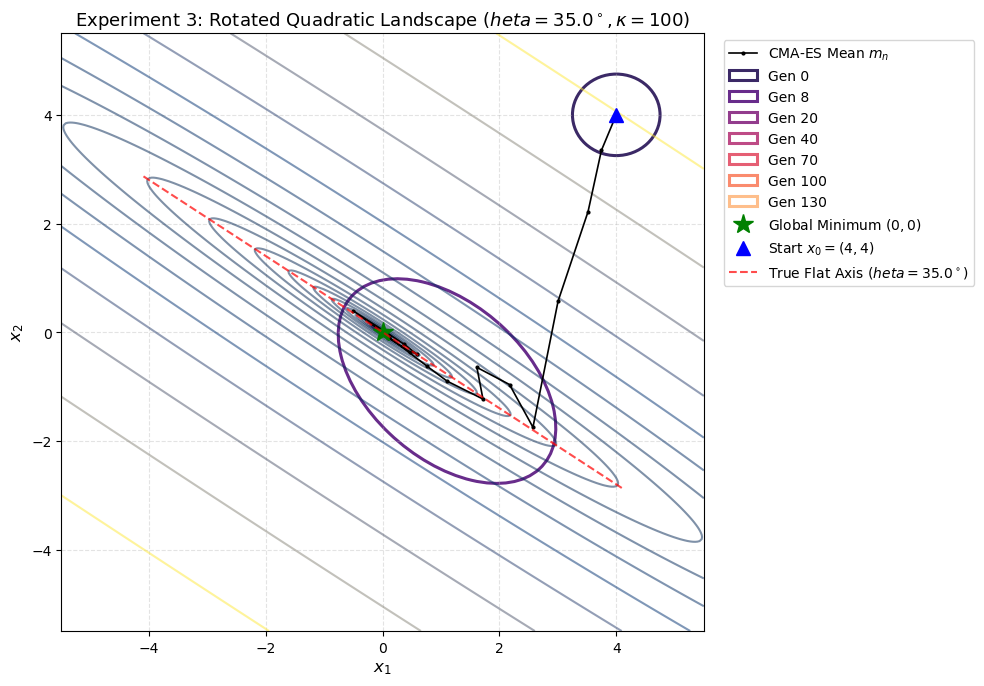

In [20]:
# Figure: Rotated Covariance Ellipse Adaptation
fig, ax = plt.subplots(figsize=(10, 7))

x_grid = np.linspace(-5.5, 5.5, 300)
y_grid = np.linspace(-5.5, 5.5, 300)
X_mesh, Y_mesh = np.meshgrid(x_grid, y_grid)
Z_mesh = np.zeros_like(X_mesh)
for i in range(X_mesh.shape[0]):
    for j in range(X_mesh.shape[1]):
        vec = np.array([X_mesh[i, j], Y_mesh[i, j]])
        Z_mesh[i, j] = vec.T @ A_rot @ vec

# Landscape contours
cs = ax.contour(X_mesh, Y_mesh, Z_mesh, levels=np.logspace(-1, 3.5, 18), cmap='cividis', alpha=0.5)

# Trajectory
means_rot = res_cma_rot['history_mean']
ax.plot(means_rot[:, 0], means_rot[:, 1], 'k.-', markersize=4, lw=1.2, label='CMA-ES Mean $m_n$')

# Plot adapting ellipses
gen_snapshots = [0, 8, 20, 40, 70, 100, 130]
colors = plt.cm.magma(np.linspace(0.15, 0.85, len(gen_snapshots)))

for i, gen in enumerate(gen_snapshots):
    if gen < len(res_cma_rot['history_C']):
        m_g = res_cma_rot['history_mean'][gen]
        C_g = res_cma_rot['history_C'][gen]
        s_g = res_cma_rot['history_sigma'][gen]
        plot_covariance_ellipse(m_g, C_g, s_g, ax, n_std=1.5, edgecolor=colors[i], 
                                lw=2.2, alpha=0.9, label=f'Gen {gen}')

ax.plot(0, 0, 'g*', markersize=15, label='Global Minimum $(0,0)$')
ax.plot(x0_rot[0], x0_rot[1], 'b^', markersize=10, label=f'Start $x_0 = (4,4)$')

# Plot theoretical principal axis of the rotated valley
t_vals = np.linspace(-5, 5, 100)
principal_dir = Q_rot[0, :]  # Eigenvector with eigenvalue 1.0 (flat axis)
ax.plot(t_vals * principal_dir[0], t_vals * principal_dir[1], 'r--', lw=1.5, alpha=0.7, label=f'True Flat Axis ($\theta={theta_deg}^\circ$)')

ax.set_title(f'Experiment 3: Rotated Quadratic Landscape ($\theta = {theta_deg}^\circ, \kappa = 100$)', fontsize=13)
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_xlim(-5.5, 5.5)
ax.set_ylim(-5.5, 5.5)
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()